# Configuration

In [1]:
import sys
import code
import os
import pickle

import pandas as pd
import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

from tqdm import tqdm
import scipy.sparse
from scipy.sparse import csr_matrix
from gtfparse import read_gtf
from collections import defaultdict
from sklearn.metrics import auc, precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt

import networkx as nx
import dill



sys.path.append('/home/liyang/BioWuYan/dygmamba_project/model/dygmamba/src/')

# 1. 加载 autoreload 扩展
%load_ext autoreload

# 2. 设置模式为 "2" (表示自动重载所有模块)
%autoreload 2

cell_type = "MCF7"
unibind_file = "/home/liyang/BioWuYan/dygmamba_project/data/cell_line/MCF7/unibind/MCF7_UniBind_search_q7fs30kp.tar.gz"

# Result

********** 开始读取数据...
正在读取压缩包: /home/liyang/BioWuYan/dygmamba_project/data/cell_line/MCF7/unibind/MCF7_UniBind_search_q7fs30kp.tar.gz ...
处理完成！
共提取了 68 个 TF 的数据。
总 Region 数量: 10359228
  chrom   start     end    TF CellLine     SourceID
0  chr1  904767  904786  CTCF     MCF7  ENCSR000AHD
1  chr1  925695  925714  CTCF     MCF7  ENCSR000AHD
2  chr1  938241  938260  CTCF     MCF7  ENCSR000AHD
3  chr1  951558  951577  CTCF     MCF7  ENCSR000AHD
4  chr1  984316  984335  CTCF     MCF7  ENCSR000AHD
   CellLine      TF  PeakCount  Rank
23     MCF7   FOXA1     100880   1.0
17     MCF7    ESR1      99509   2.0
8      MCF7    CTCF      93848   3.0
65     MCF7  TFAP2C      75207   4.0
42     MCF7   NR2F1      68778   5.0
Top 40 AUC (Raw): 455.00
Top 40 AUC (Normalized): 0.5691

步骤 1: 过滤 Peaks (行)
  > 找到 89332 / 89332 个 peaks 至少有 1 个 TF 结合。

步骤 2: 过滤 TFs (列)
  > 找到 850 / 850 个 TFs 至少结合 1 个 peak。
  > 最终形状: (89332, 850)
**************************************************
Peak-Gene: 35969, 2000, edge:202

/home/liyang/BioWuYan/dygmamba_project/model/dygmamba/src/benchmark/benchmark_model.py:436: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=df_combined,
/home/liyang/BioWuYan/dygmamba_project/model/dygmamba/src/benchmark/benchmark_model.py:451: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels)
/home/liyang/BioWuYan/dygmamba_project/model/dygmamba/src/benchmark/benchmark_model.py:505: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(data=df_combined,
/home/liyang/BioWuYan/dygmamba_project/model/dygmamba/src/benchmark/benchmark_model.py:524: UserWarning: set_ticklabels() s

FileNotFoundError: [Errno 2] Unable to synchronously open file (unable to open file: name = '/home/liyang/BioWuYan/dygmamba_project/data/cell_line/MCF7/process/tf_gene_network.h5ad', errno = 2, error message = 'No such file or directory', flags = 0, o_flags = 0)

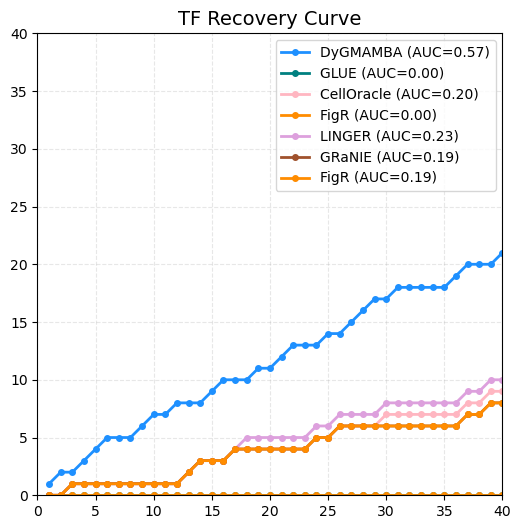

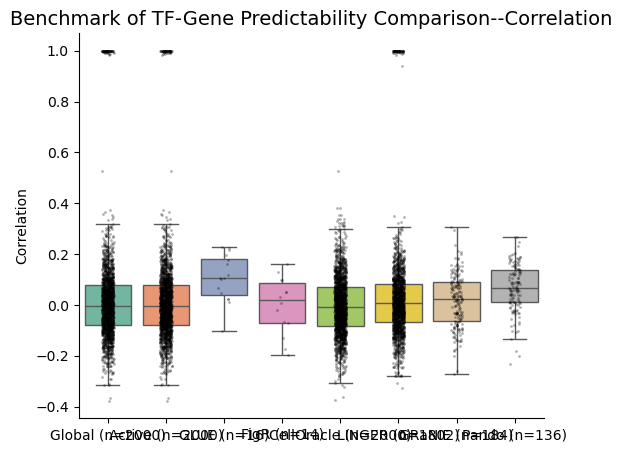

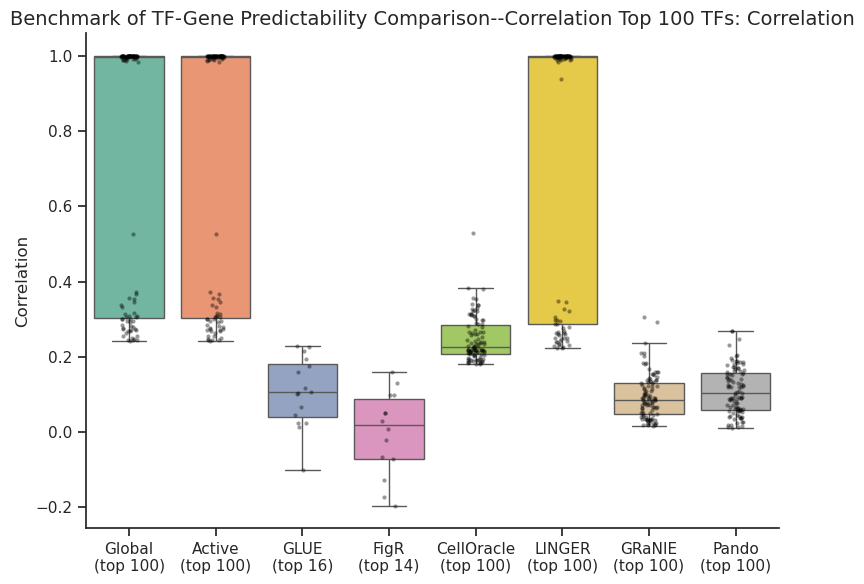

In [2]:
from pdata.data_read import read_unibind_file

data_path = "/home/liyang/BioWuYan/dygmamba_project/data/cell_line/" + cell_type + "/"

output_path = data_path + "benchmark/"

os.makedirs(output_path, exist_ok=True )

unibind_df_file = data_path + "benchmark/unibind_df.pkl"

model_result_path = data_path + "data_dyg/"

method_list = ["DyGMamba", "CellOracle", "FigR", "GLUE", "LINGER", "GRaNIE", "Pando"]

#############################################################################
#
# Unibind data processing
#
#############################################################################

unibind_df, count_region_df = read_unibind_file(unibind_file)

unibind_df["CellLine"] = unibind_df["CellLine"].str.split('_').str[0]
count_region_df["CellLine"] = count_region_df["CellLine"].str.split('_').str[0]

print(unibind_df.head())
print(count_region_df.head())

unibind_df.to_pickle(output_path + "unibind_df.pkl")
count_region_df.to_pickle(output_path + "count_region_df.pkl")


##############################################################################
#
# TF recovery
#
##############################################################################
from benchmark.benchmark_model import analysis_tf_recovery

analysis_tf_recovery(data_path, output_path, method_list)

##############################################################################
#
# TF-Gene
#
##############################################################################

from benchmark.benchmark_model import analysis_tf_gene_data, analysis_tf_gene_all_correlation, \
    plot_top_n_tf_comparison, dyg_tf_gene_result
    
from benchmark.benchmark_model import analysis_tf_gene_all_precision


tf_gene_grn, avg_active_tf_gene_grn, avg_global_tf_gene_grn = dyg_tf_gene_result(data_path, model_result_path)

result_dict = analysis_tf_gene_data( data_path, method_list )

analysis_tf_gene_all_correlation(output_path, result_dict)

###########################
# Top 100 correlation

# 1. 定义绘图顺序
my_order = ['Global', 'Active', 'GLUE', 'FigR', 'CellOracle', 'LINGER', 'GRaNIE', 'Pando']

plot_top_n_tf_comparison(result_dict, output_path, top_n=100, score_col='Correlation', my_order=my_order)

#############################
# Total correlation

result_dataframe = analysis_tf_gene_all_precision(data_path, output_path, method_list)

############################
# figure plot

sns.set_theme(style="whitegrid")
plt.figure(figsize=(5, 6))

ax = sns.barplot(x='Model', y='Precision', data=result_dataframe.sort_values('Precision', ascending=False), palette='viridis')

plt.title('Benchmark of TF-Gene Comparison of Precision', fontsize=15)
plt.xlabel('Model Name', fontsize=12)
plt.ylabel('Precision', fontsize=12)
plt.xticks(rotation=45) 

for p in ax.patches:
    ax.annotate(format(p.get_height(), '.4f'), 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points')

plt.tight_layout()
plt.savefig(output_path + 'Benchmark of TF-Gene Comparison of Precision.png', dpi=1200, bbox_inches='tight')

##############################################################################
#
# TF-Region
#
##############################################################################


from benchmark.benchmark_model import analysis_tf_region
###################################
# Benchmark

f_score = 0.1

tf_region_result = analysis_tf_region(unibind_df_file, data_path, f_score, method_list)


###################################
# 
from benchmark.benchmark_model import plot_top_n_comparison

# # 1. 准备数据字典
# tf_region_result = {
#     "DYGMAMBA": dyg_results,
#     "GLUE": glue_results,
#     "LINGER": linger_results,
#     "GRaNIE": granie_results,
#     "Pando": pando_results
# }

# 2. 调用函数
# 例如：对比前 10 个基因的 Precision
top_results = plot_top_n_comparison(
    method_dict=tf_region_result, 
    output_file=output_path + 'Benchmark of TF-Region Comparison of Top 10 Precision.png',
    top_n=10, 
    score_col="Precision"
)

# 2. 调用函数
# 例如：对比前 50 个基因的 Precision
top_results = plot_top_n_comparison(
    method_dict= tf_region_result, 
    output_file= output_path + 'Benchmark of TF-Region Comparison of Top 50 F1 Score.png',
    top_n= 50, 
    score_col= "F1"
)


###########################
# Boxplot
###########################
# precisioin

analysis_type = "Precision"
tf_region_df = []

for method_name, df in tf_region_result.items():

    tf_region_df.append(df[[analysis_type, 'Method']])

tf_region_df_combined = pd.concat(tf_region_df, ignore_index=True)

# ==========================
# @ 绘制箱形图
# ==========================
sns.set_theme(style="ticks")
plt.figure(figsize=(6, 5))

ax = sns.boxplot(data=tf_region_df_combined, 
                 x='Method',    # x轴放分组标签
                 y=analysis_type,        # y轴放数值
                 palette="Set2", # 配色方案
                 width=0.5)     # 箱子宽度

sns.stripplot(data=tf_region_df_combined, x='Method', y=analysis_type, 
              color='black', size=3, alpha=0.5, jitter=True)

plt.title("Benchmark of TF-Region Precision Comparison")
plt.ylabel("Precision")
plt.xlabel("") # 去掉 x 轴的 'Method' 字样，因为标签已经很清楚了
sns.despine()  # 去掉上方和右侧的边框，更符合学术规范

plt.savefig(output_path + 'Benchmark of TF-Region Comparison of Precision.png', dpi=1200, bbox_inches='tight')


################################
# F1 score

analysis_type = "F1"
tf_region_df = []

for method_name, df in tf_region_result.items():

    tf_region_df.append(df[[analysis_type, 'Method']])

tf_region_df_combined = pd.concat(tf_region_df, ignore_index=True)

# =============================
# @ 绘制箱形图
# =============================
sns.set_theme(style="ticks")
plt.figure(figsize=(6, 5))

ax = sns.boxplot(data=tf_region_df_combined, 
                 x='Method',    # x轴放分组标签
                 y=analysis_type,        # y轴放数值
                 palette="Set2", # 配色方案
                 width=0.5)     # 箱子宽度

sns.stripplot(data=tf_region_df_combined, x='Method', y=analysis_type, 
              color='black', size=3, alpha=0.5, jitter=True)

plt.title("Benchmark of TF-Region F1 Score Comparison")
plt.ylabel("F1 Score")
plt.xlabel("") # 去掉 x 轴的 'Method' 字样，因为标签已经很清楚了
sns.despine()  # 去掉上方和右侧的边框，更符合学术规范

plt.savefig(output_path + 'Benchmark of TF-Region Comparison of F1 Score.png', dpi=1200, bbox_inches='tight')

##############################################################################
#
# Region-Gene
#
##############################################################################

from benchmark.benchmark_model import analysis_region_gene, evaluate_r2g_benchmark, \
    plot_recovery_curves, plot_top_n_methods_comparison

results, method_data, benchmark_peak_gene_df = analysis_region_gene(data_path, output_path, method_list)

#################################
# Correlation

plot_data = results.T.reset_index()
plot_data.columns = ['Method', 'Correlation']

# 2. 绘图
plt.figure(figsize=(6, 6))
sns.set_style("whitegrid") # 设置清爽的白色网格背景

ax = sns.barplot(x='Method', y='Correlation', data=plot_data, palette='coolwarm')

for p in ax.patches:
    ax.annotate(format(p.get_height(), '.3f'), 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points')

plt.title("Benchmark pf Region-Gene correlation comparsion", fontsize=15)
plt.ylim(0, max(plot_data['Correlation']) * 1.2) # 给上方数值留点空间

plt.savefig(output_path + 'Benchmark of Region-Gene Correlation Comparison.png', dpi=1200, bbox_inches='tight')


#############################
# score analysis

corr_df, metrics_df = evaluate_r2g_benchmark(benchmark_peak_gene_df, method_data)

corr_df['Abs_Spearman_Rho'] = corr_df['Spearman_Rho'].abs()

# 调用
plot_recovery_curves(corr_df, 
                     output_file=output_path + 'Benchmark of Recovery Curve of Region-Gene Prediction.png',
                     compared_method='Abs_Spearman_Rho')

plot_top_n_methods_comparison(corr_df, 
                              output_file=output_path + 'Benchmark of Region-Gene Comparison of Top 200 Spearman Rho.png',
                              top_n=200, compare_method='Abs_Spearman_Rho')
